In [92]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [94]:
transform_train = transforms.Compose(
    [
        transforms.Resize((224,224)), #mobilenet input size
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))  #rgb

    ]
)

In [101]:
transform_test = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5,))
    ]
)

In [102]:
train_dataset = datasets.Flowers102(root="./data", split="train", transform=transform_train, download=True)

test_dataaset = datasets.Flowers102(root="./data", split="val", transform=transform_test, download=True)

In [103]:
indices =torch.randint(len(train_dataset), (5,))
samples = [train_dataset[i] for i in indices]


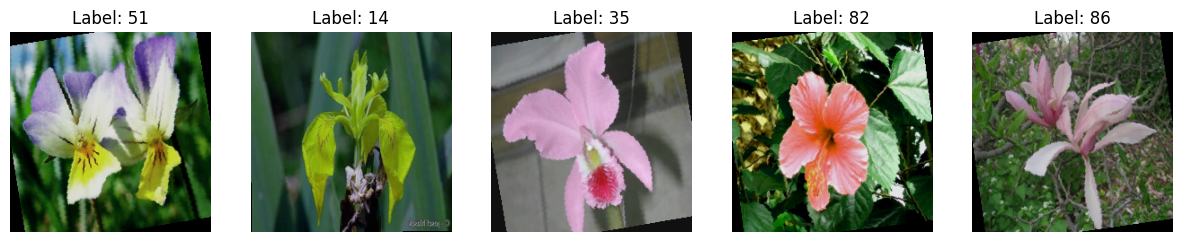

In [104]:
fig, axes = plt.subplots(1,5, figsize = (15,5))
for i, (image,label) in enumerate(samples):
    image = image.numpy().transpose((1,2,0))
    image = (image*0.5) + 0.5  # -->> [-1,1] -> [0-1]
    axes[i].imshow(image)
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.show()

In [105]:
train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(dataset=test_dataaset, batch_size=16, shuffle=False)

In [77]:
model = models.mobilenet_v2(pretrained=True)

c:\Users\Furkan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Furkan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [78]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [79]:
num_features = model.classifier[1].in_features # input features

In [80]:
model.classifier[1] = nn.Linear(in_features=num_features, out_features=102) # 102 flowers 

In [81]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=102, bias=True)
)

In [82]:
model = model.to(device=device)

In [83]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.classifier[1].parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=5, gamma=0.1) # step lr

In [84]:
epochs = 10

for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    scheduler.step()
    print(f"Epoch: {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

 10%|█         | 1/10 [00:15<02:23, 15.96s/it]

Epoch: 1, Loss: 4.4381


 20%|██        | 2/10 [00:32<02:09, 16.17s/it]

Epoch: 2, Loss: 2.5738


 30%|███       | 3/10 [00:48<01:52, 16.05s/it]

...

Epoch: 8, Loss: 0.6350


 90%|█████████ | 9/10 [02:24<00:16, 16.14s/it]

Epoch: 9, Loss: 0.6429


100%|██████████| 10/10 [02:40<00:00, 16.06s/it]

Epoch: 10, Loss: 0.6400


In [85]:
torch.save(model.state_dict(), "mobilenet_flowers102.pth")

In [106]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):  
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        
       
        _, predicted = torch.max(outputs, dim=1) 
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

100%|██████████| 64/64 [00:13<00:00,  4.67it/s]


In [111]:
cm = confusion_matrix(y_pred=all_preds, y_true=all_labels)
cm

array([[ 7,  0,  0, ...,  0,  0,  0],
       [ 0,  9,  0, ...,  0,  0,  0],
       [ 0,  0,  5, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 10,  0,  0],
       [ 0,  0,  0, ...,  0,  8,  0],
       [ 0,  0,  0, ...,  0,  0,  9]], dtype=int64)

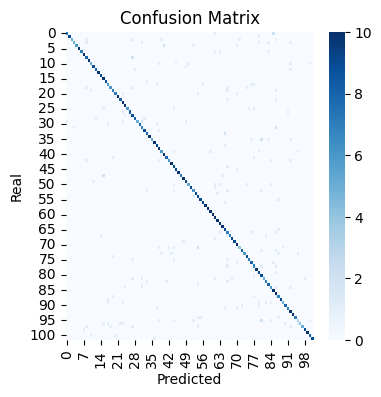

In [114]:
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()

In [115]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78        10
           1       1.00      0.90      0.95        10
           2       1.00      0.50      0.67        10
           3       0.83      0.50      0.62        10
           4       1.00      0.60      0.75        10
           5       1.00      1.00      1.00        10
           6       1.00      0.70      0.82        10
           7       0.91      1.00      0.95        10
           8       0.62      0.80      0.70        10
           9       1.00      1.00      1.00        10
          10       0.71      0.50      0.59        10
          11       0.90      0.90      0.90        10
          12       0.89      0.80      0.84        10
          13       1.00      1.00      1.00        10
          14       0.90      0.90      0.90        10
          15       0.67      1.00      0.80        10
          16       1.00      0.90      0.95        10
          17       0.60    